
🔍 드라이브에서 파일 목록을 수집하는 중...
총 발견된 WAV 파일 수: 38개

🚀 멜-스펙트로그램 특징 추출 중 (시간이 다소 소요될 수 있습니다)...
최종 훈련 데이터 형태 (X_train): (90, 64, 64, 1), 레이블 개수: 90
최종 테스트 데이터 형태 (X_test): (8, 64, 64, 1), 레이블 개수: 8


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,763 (4.36 MB)

 Trainable params: 1,141,763 (4.36 MB)

 Non-trainable params: 0 (0.00 B)


🏋️ AI 모델 학습을 시작합니다...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 355ms/step - accuracy: 0.3580 - loss: 1.0794 - val_accuracy: 0.3333 - val_loss: 1.3546
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.4321 - loss: 1.0637 - val_accuracy: 0.3333 - val_loss: 1.2222
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.4444 - loss: 1.0565 - val_accuracy: 0.3333 - val_loss: 1.1884
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.4444 - loss: 1.0486 - val_accuracy: 0.3333 - val_loss: 1.2319
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.4321 - loss: 1.0340 - val_accuracy: 0.3333 - val_loss: 1.2560
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step - accuracy: 0.4198 - loss: 1.0249 - val_accuracy: 0.3333 - val_loss: 1.2282
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step - accuracy: 0.4444 - loss: 0.9787 - val_accuracy: 0.2222 - val_loss: 1.2469
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.4444 - loss: 0.9710 - val_accur

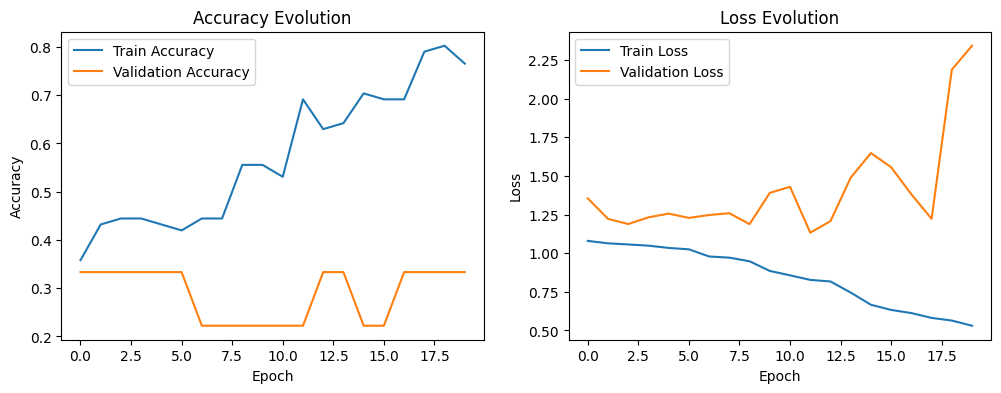

In [3]:
import os
import numpy as np
import librosa
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


# ==============================================================================
# [경로 및 설정 값]
# 앞서 .wav로 변환해둔 새 폴더 경로(dataset_wav)를 지정하는 것이 좋습니다.
# ==============================================================================
DATASET_PATH = '/content/drive/MyDrive/오디오파일wav'
classes = ['0_indoor_alarms', '1_outdoor_warnings', '2_emergency_alarms']

# 2. 데이터 전처리 함수 (사용자 제공 코드 포함)
def add_noise(data):
    noise = np.random.randn(len(data))
    return data + 0.005 * noise

def extract_mel_spectrogram(file_path, augment=False):
    # librosa.load 시 존재하지 않거나 깨진 파일 예외 처리 추가
    try:
        y, sr = librosa.load(file_path, duration=3.0)
    except Exception as e:
        return []

    features = []

    # 원본 멜-스펙트로그램 생성 및 64x64 리사이즈
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    features.append(cv2.resize(librosa.power_to_db(mel, ref=np.max), (64, 64)))

    # 데이터 증강 옵션이 켜진 경우 (훈련 데이터에만 적용)
    if augment:
        # 잡음 추가 버전
        y_noise = add_noise(y)
        mel_noise = librosa.feature.melspectrogram(y=y_noise, sr=sr)
        features.append(cv2.resize(librosa.power_to_db(mel_noise, ref=np.max), (64, 64)))

        # 음고 변경 버전
        y_pitch = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2)
        mel_pitch = librosa.feature.melspectrogram(y=y_pitch, sr=sr)
        features.append(cv2.resize(librosa.power_to_db(mel_pitch, ref=np.max), (64, 64)))

    return features

# 3. 데이터셋 파일 경로 수집
print("\n🔍 드라이브에서 파일 목록을 수집하는 중...")
file_paths = []
file_labels = []

for idx, class_name in enumerate(classes):
    class_dir = os.path.join(DATASET_PATH, class_name)
    if not os.path.exists(class_dir):
        print(f"[경고] {class_name} 폴더를 찾을 수 없습니다. 경로를 확인하세요.")
        continue

    for file in os.listdir(class_dir):
        if file.lower().endswith('.wav'):
            file_paths.append(os.path.join(class_dir, file))
            file_labels.append(idx) # 클래스 이름을 숫자(0, 1, 2) 레이블로 저장

print(f"총 발견된 WAV 파일 수: {len(file_paths)}개")

# 4. 데이터 누수를 방지하기 위해 파일 경로 기준으로 8:2 분할
X_train_paths, X_test_paths, y_train_paths, y_test_paths = train_test_split(
    file_paths, file_labels, test_size=0.2, random_state=42, stratify=file_labels
)

# 5. 실제 멜-스펙트로그램 특징 추출 및 훈련셋/테스트셋 구축
print("\n🚀 멜-스펙트로그램 특징 추출 중 (시간이 다소 소요될 수 있습니다)...")
X_train, y_train = [], []
X_test, y_test = [], []

# 훈련 데이터셋 구축 (Augment 적용하여 데이터 3배 뻥튀기)
for path, label in zip(X_train_paths, y_train_paths):
    feats = extract_mel_spectrogram(path, augment=True)
    for f in feats:
        X_train.append(f)
        y_train.append(label)

# 테스트 데이터셋 구축 (순수 원본 데이터로만 평가해야 하므로 Augment 제거)
for path, label in zip(X_test_paths, y_test_paths):
    feats = extract_mel_spectrogram(path, augment=False)
    for f in feats:
        X_test.append(f)
        y_test.append(label)

# 6. CNN 입력을 위한 텐서 변환 및 데이터 규격 맞추기
# CNN(Conv2D)은 (배치크기, 세로, 가로, 채널수)의 4차원 데이터(배치크기,세로,가로,채널 수)가 필요합니다. (흑백이므로 채널=1)
X_train = np.array(X_train)[..., np.newaxis] #(데이터개수,64,64,1)
y_train = np.array(y_train)
X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)

print(f"최종 훈련 데이터 형태 (X_train): {X_train.shape}, 레이블 개수: {len(y_train)}")
print(f"최종 테스트 데이터 형태 (X_test): {X_test.shape}, 레이블 개수: {len(y_test)}")


# 7. CNN 모델 설계
# librosa.power_to_db 결과물은 대략 -80 ~ 0 사이의 음수 값입니다.
# Rescaling 레이어를 사용해 신경망이 학습하기 좋게 0 ~ 1 사이로 정규화해줍니다.
model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Rescaling(1.0/80.0, offset=1.0), # -80~0 범위를 0~1 범위로 변환
    #멜-스펙트로그램의 값은 대략 -80에서 0 사이의 음수 데시벨(dB)입니다. 인공지능은 음수나 너무 큰 숫자가 들어오면 계산하다가 길을 잃기 쉽습니다.
    #이 레이어는 -80 ~ 0의 범위를 계산을 통해 컴퓨터가 가장 좋아하는 0.0 ~ 1.0 사이의 예쁜 양수로 변환해 줍니다.

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),#특징추출
    layers.MaxPooling2D((2, 2)),#크기 줄이기

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),#2차원->1차원
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # 과적합 방지
    layers.Dense(3, activation='softmax') # 클래스가 3개이므로 출력 노드 3, 소프트맥스
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# 8. 모델 학습 시작 (Epoch는 데이터 양에 따라 조절하세요)
print("\n🏋️ AI 모델 학습을 시작합니다...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1 # 훈련 데이터 중 10%를 검증용으로 사용
)


# 9. 테스트셋을 이용한 최종 모델 성능 검증
print("\n🧪 검증하지 않은 독립된 테스트 데이터로 최종 성능을 평가합니다...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n🎯 최종 테스트 정확도 (Test Accuracy): {test_acc * 100:.2f}%")


# 10. 학습 결과 그래프 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()